In [1]:

from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from datasets import load_from_disk
from qwen_vl_utils import process_vision_info
import os
import torch
import torch.nn.functional as F
from utils import reasoning_prompt_template, baseline_prompt_template, make_conversation_from_prompt

import dotenv
dotenv.load_dotenv()

True

In [2]:

BASELINE_MODEL = 'Qwen/Qwen2.5-VL-3B-Instruct'
REASONING_MODEL = 'Jakh0103/Qwen2.5-VL-3B-GRPO-VSR'

DATASET_PATH =  os.environ['DATA_PATH'] + "/vsr_prompt_tuning"

SOFT_PROMPT_LEN = 16


# default: Load the model on the available device(s)
reasoning_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    REASONING_MODEL, torch_dtype="auto", device_map="cuda:0"
)

baseline_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    BASELINE_MODEL, torch_dtype="auto", device_map="cuda:0"
)

# default processor
processor = AutoProcessor.from_pretrained(REASONING_MODEL, use_fast=True)

dataset = load_from_disk(DATASET_PATH)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
def obtain_logits_reasoning(item, model, prompt_template):
    # Step 1: Build full conversation (user + assistant)
    full_conversation = make_conversation_from_prompt(item, prompt_template, answer=item['desired_output'])
    
    # Step 2: Prepare full chat text with generation prompt
    full_text = processor.apply_chat_template(
        full_conversation['messages'], tokenize=False, add_generation_prompt=False
    )

    # Step 3: Prepare partial conversation (user only)
    user_only_conversation = make_conversation_from_prompt(item, prompt_template, answer=None)
    user_only_text = processor.apply_chat_template(
        user_only_conversation['messages'], tokenize=False, add_generation_prompt=True
    )

    # Step 4: Tokenize both to get the offset where assistant's tokens start
    full_ids = processor.tokenizer(full_text, return_tensors="pt")["input_ids"][0]
    user_only_ids = processor.tokenizer(user_only_text, return_tensors="pt")["input_ids"][0]
    
    offset = user_only_ids.shape[0]  # Assistant's reply starts here

    assert torch.equal(full_ids[:offset], user_only_ids), "Token mismatch before assistant's output start!"

    # Step 5: Forward pass
    image_inputs, video_inputs = process_vision_info(full_conversation['messages'])
    inputs = processor(
        text=[full_text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        logits = model(**inputs).logits[0].cpu()  # shape: [seq_len, vocab_size]

    # Step 6: Slice only assistant output logits
    assistant_logits = logits[offset:]  # only the assistant's reply

    return assistant_logits
obtain_logits_reasoning(
    dataset[0], reasoning_model, reasoning_prompt_template
).shape

torch.Size([589, 151936])

In [13]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer

class SoftPromptTuningModel(nn.Module):
    def __init__(self, base_model, tokenizer, n_tokens=20, init_from_vocab=True):
        super().__init__()
        self.base_model = base_model
        self.tokenizer = tokenizer
        self.n_tokens = n_tokens
        
        # Get the embedding dimension from the base model
        self.embedding_dim = self.base_model.get_input_embeddings().weight.shape[1]
        
        # Initialize soft prompts
        if init_from_vocab:
            # Initialize from random vocabulary tokens
            init_prompt_ids = torch.randint(
                low=0, high=len(tokenizer), size=(n_tokens,)
            )
            with torch.no_grad():
                word_embeddings = self.base_model.get_input_embeddings().weight
                soft_prompts = word_embeddings[init_prompt_ids].clone()
        else:
            # Random initialization
            soft_prompts = torch.randn(n_tokens, self.embedding_dim)
            
        # Create soft prompt as trainable parameter
        self.soft_prompt = nn.Parameter(soft_prompts, requires_grad=True)
    
    def forward(self, pixel_values=None, attention_mask=None, input_ids=None, image_grid_thw=None, **kwargs):
        # Get the input embeddings from the base model
        input_embeddings = self.base_model.get_input_embeddings()
        
        if input_ids is not None:
            # Convert input_ids to embeddings
            inputs_embeds = input_embeddings(input_ids)
            
            # Prepare soft prompts
            batch_size = input_ids.shape[0]
            soft_prompts = self.soft_prompt.repeat(batch_size, 1, 1)
            
            # Concatenate soft prompts with input embeddings
            inputs_embeds = torch.cat([soft_prompts, inputs_embeds], dim=1)
            
            # Extend attention mask for soft prompts
            if attention_mask is not None:
                prompt_attention = torch.ones(
                    batch_size, self.n_tokens, device=attention_mask.device, dtype=attention_mask.dtype
                )
                attention_mask = torch.cat([prompt_attention, attention_mask], dim=1)
            
            # Call model with embeddings instead of input_ids
            outputs = self.base_model(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                pixel_values=pixel_values,
                image_grid_thw=image_grid_thw,
                **kwargs
            )
        else:
            # If no input_ids provided, just pass everything else
            outputs = self.base_model(
                pixel_values=pixel_values,
                attention_mask=attention_mask,
                image_grid_thw=image_grid_thw,
                **kwargs
            )
            
        return outputs


# Create soft prompt tuning wrapper
soft_prompt_model = SoftPromptTuningModel(baseline_model, processor.tokenizer, n_tokens=20)

# Sample inputs
input_ids = torch.randint(0, 1000, (2, 10)).to(baseline_model.device)
attention_mask = torch.ones_like(input_ids).to(baseline_model.device)
pixel_values = torch.randn(2, 3, 224, 224).to(baseline_model.device)
image_grid_thw = [7, 7, 32] 

# Forward pass with soft prompts
outputs = soft_prompt_model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    pixel_values=pixel_values,
    image_grid_thw=image_grid_thw
)
outputs.logits.shape  # Check the shape of the output logits

torch.Size([2, 30, 151936])

In [ ]:
from unittest.mock import Base


for param in baseline_model.parameters():
    param.requires_grad = False

item = dataset[0]
desired_output = item['desired_output']
desired_logits = obtain_logits_reasoning(item, reasoning_model, reasoning_prompt_template).detach()

conversation = make_conversation_from_prompt(item, baseline_prompt_template, answer=desired_output)
image_inputs, video_inputs = process_vision_info(conversation['messages'])
inputs = processor(
    text=[desired_output],              # e.g. "<image> a dog running"
    images=image_inputs,           # PIL.Image or torch.Tensor
    videos=video_inputs,           # Optional
    return_tensors="pt",
    padding=True,
).to(baseline_model.device)
inputs.keys()

outputs = soft_prompt_model(**inputs)
outputs.keys()

odict_keys(['logits', 'past_key_values', 'rope_deltas'])

In [ ]:

input_ids = inputs.get("input_ids")         # For text tokens
pixel_values = inputs.get("pixel_values")   # For image inputs (if raw image)
inputs_embeds = inputs.get("inputs_embeds") # Some processors/models directly provide these
with torch.no_grad():
    input_embeds = baseline_model.get_input_embeddings()(input_ids)

# Prepend learned soft prompt
soft_prompt = torch.nn.Parameter(torch.randn(16, input_embeds.size(-1)).to(baseline_model.device))

# Insert prompt at the correct location
# Usually at the beginning of the text portion (after image embeddings, if present)
combined_embeds = torch.cat([soft_prompt.unsqueeze(0), input_embeds], dim=1)

# Pass in images too if needed
print(combined_embeds.shape, pixel_values.shape)
outputs = baseline_model(inputs_embeds=combined_embeds, pixel_values=pixel_values)

logits = outputs.logits[:, -input_embeds.shape[1]:, :]  # match token length



print(logits.shape, 'vs '  , desired_logits.shape)
loss = torch.nn.functional.mse_loss(logits, desired_logits)
loss.backward()
optimizer.step()





In [ ]:
def calculate_kl_divergence(item):
    # reasoning_logits: [batch_size, seq_len, vocab_size] (teacher)
    # baseline_logits: [batch_size, seq_len, vocab_size] (student)

    # TODO Change to whatever the reasoning model answers
    desired_output = item['solution']

    reasoning_logits = obtain_logits_reasoning(
        item, reasoning_model, reasoning_prompt_template, desired_output
    ).cpu()

    baseline_logits = obtain_logits_reasoning(
        item, baseline_model, baseline_prompt_template, desired_output
    ).cpu()

    # Convert to probabilities
    log_probs_baseline = F.log_softmax(baseline_logits, dim=-1)  # log Q (student)
    probs_reasoning = F.softmax(reasoning_logits, dim=-1)        # P (teacher)

    # KL divergence per token (no reduction)
    kl_per_token = F.kl_div(log_probs_baseline, probs_reasoning, reduction='none')  # [T, V]

    # Sum over vocab, mean over time steps
    kl_tokenwise = kl_per_token.sum(dim=-1)  # [T]
    kl_mean = kl_tokenwise.mean()

    return kl_mean
calculate_kl_divergence(dataset[0])

tensor(0.2778)

## Other

{'whiskers': [<matplotlib.lines.Line2D at 0x7ffa0d310820>,
 'caps': [<matplotlib.lines.Line2D at 0x7ffa09fdbfd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ffa0c8d16f0>],
 'medians': [<matplotlib.lines.Line2D at 0x7ffa09fd9f30>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ffa09fdab30>],
 'means': []}

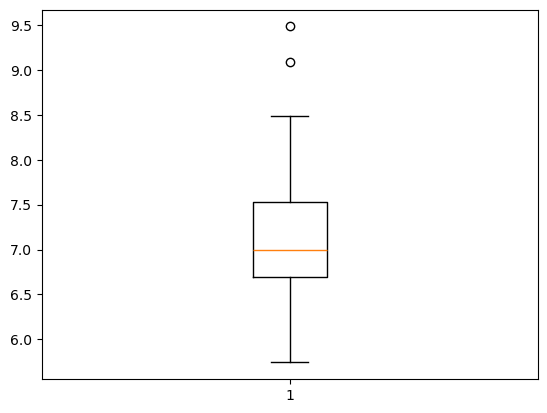

In [ ]:
import matplotlib.pyplot as plt
kl_divs = [calculate_kl_divergence(item).item() for item in dataset]
plt.boxplot(kl_divs)

{'whiskers': [<matplotlib.lines.Line2D at 0x7ffa69edac80>,
 'caps': [<matplotlib.lines.Line2D at 0x7ffa69eda410>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ffa69eda680>],
 'medians': [<matplotlib.lines.Line2D at 0x7ffa69eda140>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ffa69ed95d0>],
 'means': []}

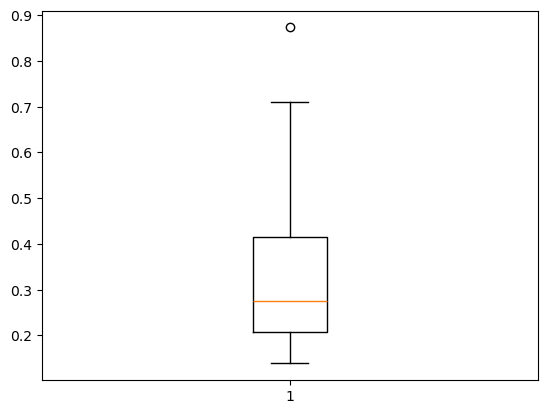

In [ ]:
import matplotlib.pyplot as plt
kl_divs = [calculate_kl_divergence(item).item() for item in dataset]
plt.boxplot(kl_divs)

In [ ]:
example = dataset[0]
prompt_template = reasoning_prompt_template
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": f"file://{example['image_path']}"},
            {"type": "text", "text": prompt_template(example)},
        ],
    }
]
print(processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False))

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Is the following statement true: The cake is next to the person. First output the thinking process in <think> </think> tags and then output the final answer in <answer> </answer> tags.<|im_end|>



In [ ]:
dataset = dataset.map(
    lambda item: {
        "kl_divergence": calculate_kl_divergence(item),
    },
    desc="Calculating KL divergence",
)

In [ ]:
# Remove tokens where input_id == tokenizer.pad_token_id
for logits in [reasoning_logits, baseline_logits]:
    ids = logits.argmax(dim=-1)
    predicted_text = processor.tokenizer.decode(ids, skip_special_tokens=True)
    
    print("Predicted assistant output:", predicted_text)


Predicted assistant output:  treesriage树 and horse parked to to具 to pole or or in buildings, buildings building building with stripeded striped decorations and square trees horse and horse white head light horse and horse and and交通 blinds)) truck striped with up for trees with hair mane with mane being mane on hair in with background or with rac building with and, harness, harness black, covering withana blue and horse and wearing white and of, background and and brown and and balls and, leather and carriage and beads red br and br bus, bus and and white or back brown, a hal, horse and metal rein with beadsoms and brown with sign waiting, cars other black
 on horse with for and horse brown equipment具 leather and white beads with with, with a and of rear line) from horse in brown and on, head leather black black and red ballsitunes to blue blue, background and and

 a a horse reins flags pipe blue with harness and h face ball keys j
 rear in car in car parked car and reins on harness h 

In [ ]:
# ONLY FOR DEBUGGING    
item = dataset[1]

# Preparation for inference
text = processor.apply_chat_template(
    item['messages'], tokenize=False, add_generation_prompt=True
)

print("INPUT:")
print(text)
print("="*20)

image_inputs, video_inputs = process_vision_info(item['messages'])
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(reasoning_model.device)

# Inference: Generation of the output
generated_ids = reasoning_model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print("OUTPUT:")
print(output_text)
print("="*20)

KeyError: 'messages'

In [ ]:
)
print("INPUT:")
print(text)
print("="*20)

image_inputs, video_inputs = process_vision_info(item['messages'])
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(reasoning_model.device)

# Inference: Generation of the output
generated_ids = reasoning_model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print("OUTPUT:")
print(output_text)
print("="*20)